In [4]:
# %%bash
# set -e

# FILE_ID="1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA"
# BASE_DIR="/home/jovyan/work/pinn/super_image"
# OUT="${BASE_DIR}/dataset.zip"
# DATA_DIR="${BASE_DIR}/dataset"

# mkdir -p "${BASE_DIR}"

# # Skip download if already present
# if [ ! -s "${OUT}" ]; then
#   python -m pip -q install --user gdown
#   python -m gdown "https://drive.google.com/uc?id=${FILE_ID}" -O "${OUT}"
# fi

# ls -lh "${OUT}"

# # Validate zip and extract
# python - <<'PY'
# import zipfile, sys
# p = "/home/jovyan/work/pinn/super_image/dataset.zip"
# ok = zipfile.is_zipfile(p)
# print("is_zipfile:", ok)
# if not ok:
#     sys.exit(1)
# PY

# mkdir -p "${DATA_DIR}"
# unzip -o -q "${OUT}" -d "${DATA_DIR}"
# du -sh "${DATA_DIR}"


Downloading...
From (original): https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA
m (redirected): https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA&confirm=t&uuid=d08d618b-3b86-4c86-bdf4-fd9a3e4deac3
To: /home/jovyan/work/pinn/super_image/dataset.zip
100%|██████████| 304M/304M [00:02<00:00, 129MB/s]  


-rw-r--r-- 1 jovyan root 290M Feb 23  2024 /home/jovyan/work/pinn/super_image/dataset.zip
is_zipfile: True
1.8G	/home/jovyan/work/pinn/super_image/dataset


In [1]:
!pip -q install transformers
!pip install --user scipy==1.14.1 numpy==1.26.4 --force-reinstall
!pip -q install transformer_lens
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124 -q
!pip -q install timm
!pip install -q einops accelerate ema-pytorch torch_fidelity




  Using cached scipy-1.14.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.14.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (41.2 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppre

In [1]:
import math
import copy
import os
import random
import numpy as np
from pathlib import Path
from functools import partial, wraps
from collections import namedtuple
from multiprocessing import cpu_count
from packaging import version

import torch
from torch import nn, einsum
import torch.nn.functional as F
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import transforms, utils
from PIL import Image
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange
from tqdm.auto import tqdm
from ema_pytorch import EMA
from accelerate import Accelerator

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Found 10000 images


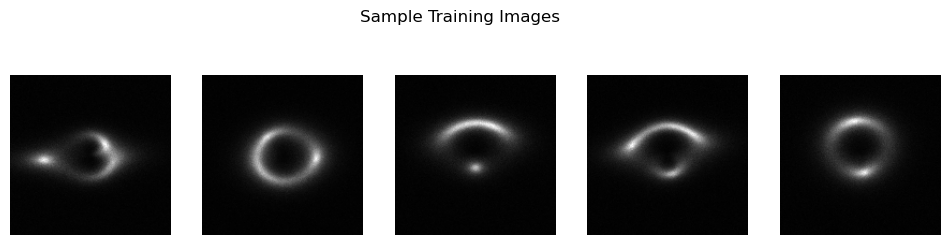

In [2]:
# ===== CONFIGURATION =====
data_folder_path = '/home/jovyan/work/pinn/super_image/dataset/Samples'
result_folder_path = '/home/jovyan/work/pinn/super_image/results'

# Create results folder
os.makedirs(result_folder_path, exist_ok=True)

# Get image paths
def data_dir_to_path(my_dir_path):
    image_list = os.listdir(my_dir_path)
    paths = [os.path.join(my_dir_path, img) for img in image_list]
    return paths

image_path = data_dir_to_path(data_folder_path)
print(f"Found {len(image_path)} images")

# Visualize sample images
fig, axs = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    idx = random.randrange(len(image_path))
    img = np.load(image_path[idx])
    axs[i].imshow(img[0, :, :], cmap='gray')
    axs[i].axis('off')
plt.suptitle('Sample Training Images')
plt.show()

In [3]:
AttentionConfig = namedtuple('AttentionConfig', ['enable_flash', 'enable_math', 'enable_mem_efficient'])

def exists(val):
    return val is not None

def default(val, d):
    if exists(val):
        return val
    return d() if callable(d) else d

def once(fn):
    called = False
    @wraps(fn)
    def inner(x):
        nonlocal called
        if called:
            return
        called = True
        return fn(x)
    return inner

print_once = once(print)

class Attend(nn.Module):
    def __init__(self, dropout=0., flash=False, scale=None):
        super().__init__()
        self.dropout = dropout
        self.scale = scale
        self.attn_dropout = nn.Dropout(dropout)
        self.flash = flash
        
        assert not (flash and version.parse(torch.__version__) < version.parse('2.0.0')), \
            'flash attention requires pytorch 2.0+'
        
        self.cpu_config = AttentionConfig(True, True, True)
        self.cuda_config = None
        
        if not torch.cuda.is_available() or not flash:
            return
        
        device_properties = torch.cuda.get_device_properties(torch.device('cuda'))
        if device_properties.major == 8 and device_properties.minor == 0:
            print_once('A100 GPU detected, using flash attention')
            self.cuda_config = AttentionConfig(True, False, False)
        else:
            print_once('Non-A100 GPU detected, using math or mem efficient attention')
            self.cuda_config = AttentionConfig(False, True, True)

    def flash_attn(self, q, k, v):
        _, heads, q_len, _, k_len, is_cuda, device = *q.shape, k.shape[-2], q.is_cuda, q.device
        
        if exists(self.scale):
            default_scale = q.shape[-1]
            q = q * (self.scale / default_scale)
        
        q, k, v = map(lambda t: t.contiguous(), (q, k, v))
        config = self.cuda_config if is_cuda else self.cpu_config
        
        with torch.backends.cuda.sdp_kernel(**config._asdict()):
            out = F.scaled_dot_product_attention(
                q, k, v,
                dropout_p=self.dropout if self.training else 0.
            )
        return out

    def forward(self, q, k, v):
        if self.flash:
            return self.flash_attn(q, k, v)
        
        scale = default(self.scale, q.shape[-1] ** -0.5)
        sim = einsum("b h i d, b h j d -> b h i j", q, k) * scale
        attn = sim.softmax(dim=-1)
        attn = self.attn_dropout(attn)
        out = einsum("b h i j, b h j d -> b h i d", attn, v)
        return out

In [4]:
ModelPrediction = namedtuple('ModelPrediction', ['pred_noise', 'pred_x_start'])

def cast_tuple(t, length=1):
    return t if isinstance(t, tuple) else ((t,) * length)

def divisible_by(numer, denom):
    return (numer % denom) == 0

def identity(t, *args, **kwargs):
    return t

def cycle(dl):
    while True:
        for data in dl:
            yield data

def has_int_squareroot(num):
    return (math.sqrt(num) ** 2) == num

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

def normalize_to_neg_one_to_one(img):
    return img * 2 - 1

def unnormalize_to_zero_to_one(t):
    return (t + 1) * 0.5

def Upsample(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(dim, default(dim_out, dim), 3, padding=1)
    )

def Downsample(dim, dim_out=None):
    return nn.Sequential(
        Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
        nn.Conv2d(dim * 4, default(dim_out, dim), 1)
    )

class RMSNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))

    def forward(self, x):
        return F.normalize(x, dim=1) * self.g * (x.shape[1] ** 0.5)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim, theta=10000):
        super().__init__()
        self.dim = dim
        self.theta = theta

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(self.theta) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class Block(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)
        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift
        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, dim_out * 2)
        ) if exists(time_emb_dim) else None

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        scale_shift = None
        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            time_emb = rearrange(time_emb, 'b c -> b c 1 1')
            scale_shift = time_emb.chunk(2, dim=1)

        h = self.block1(x, scale_shift=scale_shift)
        h = self.block2(h)
        return h + self.res_conv(x)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32, num_mem_kv=4):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads

        self.norm = RMSNorm(dim)
        self.mem_kv = nn.Parameter(torch.randn(2, heads, dim_head, num_mem_kv))
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Sequential(
            nn.Conv2d(hidden_dim, dim, 1),
            RMSNorm(dim)
        )

    def forward(self, x):
        b, c, h, w = x.shape
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads), qkv)

        mk, mv = map(lambda t: repeat(t, 'h c n -> b h c n', b=b), self.mem_kv)
        k, v = map(partial(torch.cat, dim=-1), ((mk, k), (mv, v)))

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)
        q = q * self.scale

        context = torch.einsum('b h d n, b h e n -> b h d e', k, v)
        out = torch.einsum('b h d e, b h d n -> b h e n', context, q)
        out = rearrange(out, 'b h c (x y) -> b (h c) x y', h=self.heads, x=h, y=w)
        return self.to_out(out)

class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32, num_mem_kv=4, flash=False):
        super().__init__()
        self.heads = heads
        hidden_dim = dim_head * heads

        self.norm = RMSNorm(dim)
        self.attend = Attend(flash=flash)
        self.mem_kv = nn.Parameter(torch.randn(2, heads, num_mem_kv, dim_head))
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, 'b (h c) x y -> b h (x y) c', h=self.heads), qkv)

        mk, mv = map(lambda t: repeat(t, 'h n d -> b h n d', b=b), self.mem_kv)
        k, v = map(partial(torch.cat, dim=-2), ((mk, k), (mv, v)))

        out = self.attend(q, k, v)
        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)

In [5]:
class Unet(nn.Module):
    def __init__(
        self,
        dim,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4, 8),
        channels=1,
        self_condition=False,
        resnet_block_groups=8,
        learned_variance=False,
        sinusoidal_pos_emb_theta=10000,
        attn_dim_head=32,
        attn_heads=4,
        full_attn=None,
        flash_attn=False
    ):
        super().__init__()

        self.channels = channels
        self.self_condition = self_condition
        input_channels = channels * (2 if self_condition else 1)

        init_dim = default(init_dim, dim)
        self.init_conv = nn.Conv2d(input_channels, init_dim, 7, padding=3)

        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        block_klass = partial(ResnetBlock, groups=resnet_block_groups)

        # Time embeddings
        time_dim = dim * 4
        sinu_pos_emb = SinusoidalPosEmb(dim, theta=sinusoidal_pos_emb_theta)

        self.time_mlp = nn.Sequential(
            sinu_pos_emb,
            nn.Linear(dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )

        # Attention
        if not full_attn:
            full_attn = (*((False,) * (len(dim_mults) - 1)), True)

        num_stages = len(dim_mults)
        full_attn = cast_tuple(full_attn, num_stages)
        attn_heads = cast_tuple(attn_heads, num_stages)
        attn_dim_head = cast_tuple(attn_dim_head, num_stages)

        FullAttention = partial(Attention, flash=flash_attn)

        # Down blocks
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, ((dim_in, dim_out), layer_full_attn, layer_attn_heads, layer_attn_dim_head) in enumerate(zip(in_out, full_attn, attn_heads, attn_dim_head)):
            is_last = ind >= (num_resolutions - 1)
            attn_klass = FullAttention if layer_full_attn else LinearAttention

            self.downs.append(nn.ModuleList([
                block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                attn_klass(dim_in, dim_head=layer_attn_dim_head, heads=layer_attn_heads),
                Downsample(dim_in, dim_out) if not is_last else nn.Conv2d(dim_in, dim_out, 3, padding=1)
            ]))

        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = FullAttention(mid_dim, heads=attn_heads[-1], dim_head=attn_dim_head[-1])
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)

        for ind, ((dim_in, dim_out), layer_full_attn, layer_attn_heads, layer_attn_dim_head) in enumerate(zip(*map(reversed, (in_out, full_attn, attn_heads, attn_dim_head)))):
            is_last = ind == (len(in_out) - 1)
            attn_klass = FullAttention if layer_full_attn else LinearAttention

            self.ups.append(nn.ModuleList([
                block_klass(dim_out + dim_in, dim_out, time_emb_dim=time_dim),
                block_klass(dim_out + dim_in, dim_out, time_emb_dim=time_dim),
                attn_klass(dim_out, dim_head=layer_attn_dim_head, heads=layer_attn_heads),
                Upsample(dim_out, dim_in) if not is_last else nn.Conv2d(dim_out, dim_in, 3, padding=1)
            ]))

        default_out_dim = channels * (1 if not learned_variance else 2)
        self.out_dim = default(out_dim, default_out_dim)

        self.final_res_block = block_klass(dim * 2, dim, time_emb_dim=time_dim)
        self.final_conv = nn.Conv2d(dim, self.out_dim, 1)

    @property
    def downsample_factor(self):
        return 2 ** (len(self.downs) - 1)

    def forward(self, x, time, x_self_cond=None):
        assert all([divisible_by(d, self.downsample_factor) for d in x.shape[-2:]]), \
            f'input dimensions {x.shape[-2:]} must be divisible by {self.downsample_factor}'

        if self.self_condition:
            x_self_cond = default(x_self_cond, lambda: torch.zeros_like(x))
            x = torch.cat((x_self_cond, x), dim=1)

        x = self.init_conv(x)
        r = x.clone()

        t = self.time_mlp(time)

        h = []

        for block1, block2, attn, downsample in self.downs:
            x = block1(x, t)
            h.append(x)
            x = block2(x, t)
            x = attn(x) + x
            h.append(x)
            x = downsample(x)

        x = self.mid_block1(x, t)
        x = self.mid_attn(x) + x
        x = self.mid_block2(x, t)

        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = block1(x, t)
            x = torch.cat((x, h.pop()), dim=1)
            x = block2(x, t)
            x = attn(x) + x
            x = upsample(x)

        x = torch.cat((x, r), dim=1)
        x = self.final_res_block(x, t)
        return self.final_conv(x)

In [6]:
def extract(a, t, x_shape):
    b, *_ = t.shape
    out = a.gather(-1, t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

def sigmoid_beta_schedule(timesteps, start=-3, end=3, tau=1, clamp_min=1e-5):
    """Sigmoid beta schedule - THIS IS CRITICAL FOR GOOD RESULTS"""
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps, dtype=torch.float64) / timesteps
    v_start = torch.tensor(start / tau).sigmoid()
    v_end = torch.tensor(end / tau).sigmoid()
    alphas_cumprod = (-((t * (end - start) + start) / tau).sigmoid() + v_end) / (v_end - v_start)
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

class GaussianDiffusion(nn.Module):
    def __init__(
        self,
        model,
        *,
        image_size,
        timesteps=1000,
        sampling_timesteps=None,
        objective='pred_x0',  # CRITICAL: use pred_x0, not pred_noise
        beta_schedule='sigmoid',  # CRITICAL: use sigmoid
        ddim_sampling_eta=0.,
        auto_normalize=True,
        offset_noise_strength=0.,
        min_snr_loss_weight=False,
        min_snr_gamma=5
    ):
        super().__init__()
        assert not (type(self) == GaussianDiffusion and model.channels != model.out_dim)

        self.model = model
        self.channels = self.model.channels
        self.self_condition = self.model.self_condition
        self.image_size = image_size
        self.objective = objective

        assert objective in {'pred_noise', 'pred_x0', 'pred_v'}

        # CRITICAL: Use sigmoid beta schedule
        betas = sigmoid_beta_schedule(timesteps)

        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.)

        timesteps, = betas.shape
        self.num_timesteps = int(timesteps)

        self.sampling_timesteps = default(sampling_timesteps, timesteps)
        assert self.sampling_timesteps <= timesteps
        self.is_ddim_sampling = self.sampling_timesteps < timesteps
        self.ddim_sampling_eta = ddim_sampling_eta

        register_buffer = lambda name, val: self.register_buffer(name, val.to(torch.float32))

        register_buffer('betas', betas)
        register_buffer('alphas_cumprod', alphas_cumprod)
        register_buffer('alphas_cumprod_prev', alphas_cumprod_prev)

        register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))
        register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1. - alphas_cumprod))
        register_buffer('log_one_minus_alphas_cumprod', torch.log(1. - alphas_cumprod))
        register_buffer('sqrt_recip_alphas_cumprod', torch.sqrt(1. / alphas_cumprod))
        register_buffer('sqrt_recipm1_alphas_cumprod', torch.sqrt(1. / alphas_cumprod - 1))

        posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)
        register_buffer('posterior_variance', posterior_variance)
        register_buffer('posterior_log_variance_clipped', torch.log(posterior_variance.clamp(min=1e-20)))
        register_buffer('posterior_mean_coef1', betas * torch.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))
        register_buffer('posterior_mean_coef2', (1. - alphas_cumprod_prev) * torch.sqrt(alphas) / (1. - alphas_cumprod))

        self.offset_noise_strength = offset_noise_strength

        snr = alphas_cumprod / (1 - alphas_cumprod)
        maybe_clipped_snr = snr.clone()
        if min_snr_loss_weight:
            maybe_clipped_snr.clamp_(max=min_snr_gamma)

        if objective == 'pred_noise':
            register_buffer('loss_weight', maybe_clipped_snr / snr)
        elif objective == 'pred_x0':
            register_buffer('loss_weight', maybe_clipped_snr)
        elif objective == 'pred_v':
            register_buffer('loss_weight', maybe_clipped_snr / (snr + 1))

        self.normalize = normalize_to_neg_one_to_one if auto_normalize else identity
        self.unnormalize = unnormalize_to_zero_to_one if auto_normalize else identity

    @property
    def device(self):
        return self.betas.device

    def predict_start_from_noise(self, x_t, t, noise):
        return (
            extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t -
            extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape) * noise
        )

    def predict_noise_from_start(self, x_t, t, x0):
        return (
            (extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t - x0) /
            extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape)
        )

    def predict_v(self, x_start, t, noise):
        return (
            extract(self.sqrt_alphas_cumprod, t, x_start.shape) * noise -
            extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape) * x_start
        )

    def predict_start_from_v(self, x_t, t, v):
        return (
            extract(self.sqrt_alphas_cumprod, t, x_t.shape) * x_t -
            extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape) * v
        )

    def q_posterior(self, x_start, x_t, t):
        posterior_mean = (
            extract(self.posterior_mean_coef1, t, x_t.shape) * x_start +
            extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = extract(self.posterior_variance, t, x_t.shape)
        posterior_log_variance_clipped = extract(self.posterior_log_variance_clipped, t, x_t.shape)
        return posterior_mean, posterior_variance, posterior_log_variance_clipped

    def model_predictions(self, x, t, x_self_cond=None, clip_x_start=False, rederive_pred_noise=False):
        model_output = self.model(x, t, x_self_cond)
        maybe_clip = partial(torch.clamp, min=-1., max=1.) if clip_x_start else identity

        if self.objective == 'pred_noise':
            pred_noise = model_output
            x_start = self.predict_start_from_noise(x, t, pred_noise)
            x_start = maybe_clip(x_start)
            if clip_x_start and rederive_pred_noise:
                pred_noise = self.predict_noise_from_start(x, t, x_start)

        elif self.objective == 'pred_x0':
            x_start = model_output
            x_start = maybe_clip(x_start)
            pred_noise = self.predict_noise_from_start(x, t, x_start)

        elif self.objective == 'pred_v':
            v = model_output
            x_start = self.predict_start_from_v(x, t, v)
            x_start = maybe_clip(x_start)
            pred_noise = self.predict_noise_from_start(x, t, x_start)

        return ModelPrediction(pred_noise, x_start)

    def p_mean_variance(self, x, t, x_self_cond=None, clip_denoised=True):
        preds = self.model_predictions(x, t, x_self_cond)
        x_start = preds.pred_x_start

        if clip_denoised:
            x_start.clamp_(-1., 1.)

        model_mean, posterior_variance, posterior_log_variance = self.q_posterior(x_start=x_start, x_t=x, t=t)
        return model_mean, posterior_variance, posterior_log_variance, x_start

    @torch.inference_mode()
    def ddim_sample(self, shape, return_all_timesteps=False):
        batch, device, total_timesteps, sampling_timesteps, eta, objective = \
            shape[0], self.device, self.num_timesteps, self.sampling_timesteps, self.ddim_sampling_eta, self.objective

        times = torch.linspace(-1, total_timesteps - 1, steps=sampling_timesteps + 1)
        times = list(reversed(times.int().tolist()))
        time_pairs = list(zip(times[:-1], times[1:]))

        img = torch.randn(shape, device=device)
        imgs = [img]
        x_start = None

        for time, time_next in tqdm(time_pairs, desc='sampling loop time step'):
            time_cond = torch.full((batch,), time, device=device, dtype=torch.long)
            self_cond = x_start if self.self_condition else None
            pred_noise, x_start, *_ = self.model_predictions(img, time_cond, self_cond, clip_x_start=True, rederive_pred_noise=True)

            if time_next < 0:
                img = x_start
                imgs.append(img)
                continue

            alpha = self.alphas_cumprod[time]
            alpha_next = self.alphas_cumprod[time_next]

            sigma = eta * ((1 - alpha / alpha_next) * (1 - alpha_next) / (1 - alpha)).sqrt()
            c = (1 - alpha_next - sigma ** 2).sqrt()

            noise = torch.randn_like(img)
            img = x_start * alpha_next.sqrt() + c * pred_noise + sigma * noise
            imgs.append(img)

        ret = img if not return_all_timesteps else torch.stack(imgs, dim=1)
        ret = self.unnormalize(ret)
        return ret

    @torch.inference_mode()
    def sample(self, batch_size=16, return_all_timesteps=False):
        image_size, channels = self.image_size, self.channels
        return self.ddim_sample((batch_size, channels, image_size, image_size), return_all_timesteps=return_all_timesteps)

    @autocast(enabled=False)
    def q_sample(self, x_start, t, noise=None):
        noise = default(noise, lambda: torch.randn_like(x_start))
        return (
            extract(self.sqrt_alphas_cumprod, t, x_start.shape) * x_start +
            extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape) * noise
        )

    def p_losses(self, x_start, t, noise=None, offset_noise_strength=None):
        b, c, h, w = x_start.shape
        noise = default(noise, lambda: torch.randn_like(x_start))

        offset_noise_strength = default(offset_noise_strength, self.offset_noise_strength)
        if offset_noise_strength > 0.:
            offset_noise = torch.randn(x_start.shape[:2], device=self.device)
            noise += offset_noise_strength * rearrange(offset_noise, 'b c -> b c 1 1')

        x = self.q_sample(x_start=x_start, t=t, noise=noise)

        x_self_cond = None
        if self.self_condition and random.random() < 0.5:
            with torch.no_grad():
                x_self_cond = self.model_predictions(x, t).pred_x_start
                x_self_cond.detach_()

        model_out = self.model(x, t, x_self_cond)

        if self.objective == 'pred_noise':
            target = noise
        elif self.objective == 'pred_x0':
            target = x_start
        elif self.objective == 'pred_v':
            target = self.predict_v(x_start, t, noise)
        else:
            raise ValueError(f'unknown objective {self.objective}')

        loss = F.mse_loss(model_out, target, reduction='none')
        loss = reduce(loss, 'b ... -> b', 'mean')
        loss = loss * extract(self.loss_weight, t, loss.shape)
        return loss.mean()

    def forward(self, img, *args, **kwargs):
        b, c, h, w, device, img_size = *img.shape, img.device, self.image_size
        assert h == img_size and w == img_size, f'height and width must be {img_size}'
        t = torch.randint(0, self.num_timesteps, (b,), device=device).long()
        img = self.normalize(img)
        return self.p_losses(img, t, *args, **kwargs)

/tmp/ipykernel_663/3320944031.py:207: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


In [7]:
class LensingDataset(Dataset):
    """Dataset for gravitational lensing images with PROPER preprocessing"""
    def __init__(self, image_paths, image_size=128):
        super().__init__()
        self.image_paths = image_paths
        self.image_size = image_size
        
        # CRITICAL: CenterCrop to 128 (divisible by 8)
        self.transform = transforms.Compose([
            transforms.CenterCrop(128),  # Original is 150, crop to 128
            transforms.ToTensor(),
        ])
        
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_filepath = self.image_paths[idx]
        image = np.load(image_filepath)
        image = image.reshape(150, 150)
        
        # Convert to PIL Image (scale to 0-255)
        image = Image.fromarray(np.uint8(image * 255), 'L')
        
        # Apply transforms (CenterCrop + ToTensor)
        image = self.transform(image)
        return image

In [8]:
class Trainer(object):
    def __init__(
        self,
        diffusion_model,
        folder,
        *,
        train_batch_size=16,
        gradient_accumulate_every=1,
        train_lr=1e-4,
        train_num_steps=100000,
        ema_update_every=10,
        ema_decay=0.995,
        adam_betas=(0.9, 0.99),
        save_and_sample_every=10000,
        num_samples=16,
        results_folder=result_folder_path,
        amp=False,
        mixed_precision_type='fp16',
        split_batches=True,
        max_grad_norm=1.,
    ):
        super().__init__()

        self.accelerator = Accelerator(
            split_batches=split_batches,
            mixed_precision=mixed_precision_type if amp else 'no'
        )

        self.model = diffusion_model
        self.channels = diffusion_model.channels
        self.num_samples = num_samples
        self.save_and_sample_every = save_and_sample_every
        self.batch_size = train_batch_size
        self.gradient_accumulate_every = gradient_accumulate_every
        self.train_num_steps = train_num_steps
        self.image_size = diffusion_model.image_size
        self.max_grad_norm = max_grad_norm

        # Dataset with PROPER preprocessing
        self.ds = LensingDataset(image_path, image_size=128)
        
        assert len(self.ds) >= 100, 'need at least 100 images'
        print(f"Dataset size: {len(self.ds)} images")

        dl = DataLoader(self.ds, batch_size=train_batch_size, shuffle=True, pin_memory=True, num_workers=cpu_count())
        dl = self.accelerator.prepare(dl)
        self.dl = cycle(dl)

        self.opt = Adam(diffusion_model.parameters(), lr=train_lr, betas=adam_betas)

        if self.accelerator.is_main_process:
            self.ema = EMA(diffusion_model, beta=ema_decay, update_every=ema_update_every)
            self.ema.to(self.device)

        self.results_folder = Path(results_folder)
        self.results_folder.mkdir(exist_ok=True)

        self.step = 0
        self.model, self.opt = self.accelerator.prepare(self.model, self.opt)

    @property
    def device(self):
        return self.accelerator.device

    def save(self, milestone):
        if not self.accelerator.is_local_main_process:
            return

        data = {
            'step': self.step,
            'model': self.accelerator.get_state_dict(self.model),
            'opt': self.opt.state_dict(),
            'ema': self.ema.state_dict(),
            'scaler': self.accelerator.scaler.state_dict() if exists(self.accelerator.scaler) else None,
        }
        torch.save(data, str(self.results_folder / f'model-{milestone}.pt'))

    def load(self, path):
        accelerator = self.accelerator
        device = accelerator.device

        data = torch.load(path, map_location=device)

        model = self.accelerator.unwrap_model(self.model)
        model.load_state_dict(data['model'])

        self.step = data['step']
        self.opt.load_state_dict(data['opt'])
        
        if self.accelerator.is_main_process:
            self.ema.load_state_dict(data["ema"])

        if exists(self.accelerator.scaler) and exists(data['scaler']):
            self.accelerator.scaler.load_state_dict(data['scaler'])

    def train(self):
        accelerator = self.accelerator
        device = accelerator.device

        with tqdm(initial=self.step, total=self.train_num_steps, disable=not accelerator.is_main_process) as pbar:
            while self.step < self.train_num_steps:
                total_loss = 0.

                for _ in range(self.gradient_accumulate_every):
                    data = next(self.dl).to(device)

                    with self.accelerator.autocast():
                        loss = self.model(data)
                        loss = loss / self.gradient_accumulate_every
                        total_loss += loss.item()

                    self.accelerator.backward(loss)

                pbar.set_description(f'loss: {total_loss:.4f}')

                accelerator.wait_for_everyone()
                accelerator.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)

                self.opt.step()
                self.opt.zero_grad()

                accelerator.wait_for_everyone()

                self.step += 1
                if accelerator.is_main_process:
                    self.ema.update()

                    if self.step != 0 and divisible_by(self.step, self.save_and_sample_every):
                        self.ema.ema_model.eval()

                        with torch.inference_mode():
                            milestone = self.step // self.save_and_sample_every
                            batches = num_to_groups(self.num_samples, self.batch_size)
                            all_images_list = list(map(lambda n: self.ema.ema_model.sample(batch_size=n), batches))

                        all_images = torch.cat(all_images_list, dim=0)
                        utils.save_image(all_images, str(self.results_folder / f'sample-{milestone}.png'), nrow=int(math.sqrt(self.num_samples)))
                        self.save(milestone)

                pbar.update(1)

        accelerator.print('training complete')

In [9]:
# ===== CREATE MODEL =====
# CRITICAL: dim=32, dim_mults=(1, 2, 2, 4) to match working code
model = Unet(
    dim=32,
    dim_mults=(1, 2, 2, 4),  # 3 downsampling layers, need image divisible by 8
    flash_attn=True,
    channels=1
)

# CRITICAL: image_size=128, objective='pred_x0', beta_schedule='sigmoid'
diffusion = GaussianDiffusion(
    model,
    image_size=128,          # MUST be 128 (divisible by 8)
    timesteps=1000,
    sampling_timesteps=1000,
    objective='pred_x0',     # CRITICAL: predict x0, not noise
    beta_schedule='sigmoid'  # CRITICAL: sigmoid schedule
)

# Create trainer
trainer = Trainer(
    diffusion,
    data_folder_path,
    train_batch_size=16,
    train_lr=8e-5,
    train_num_steps=100000,
    gradient_accumulate_every=1,
    ema_decay=0.995,
    amp=True,
    results_folder=result_folder_path
)

print("Model created successfully!")
print(f"Image size: 128 (CenterCropped from 150)")
print(f"Objective: pred_x0")
print(f"Beta schedule: sigmoid")
print(f"Architecture: dim=32, dim_mults=(1, 2, 2, 4)")

Non-A100 GPU detected, using math or mem efficient attention
Dataset size: 10000 images
Model created successfully!
Image size: 128 (CenterCropped from 150)
Objective: pred_x0
Beta schedule: sigmoid
Architecture: dim=32, dim_mults=(1, 2, 2, 4)


In [10]:
# Train from scratch
trainer.train()

  0%|          | 0/100000 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

training complete


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

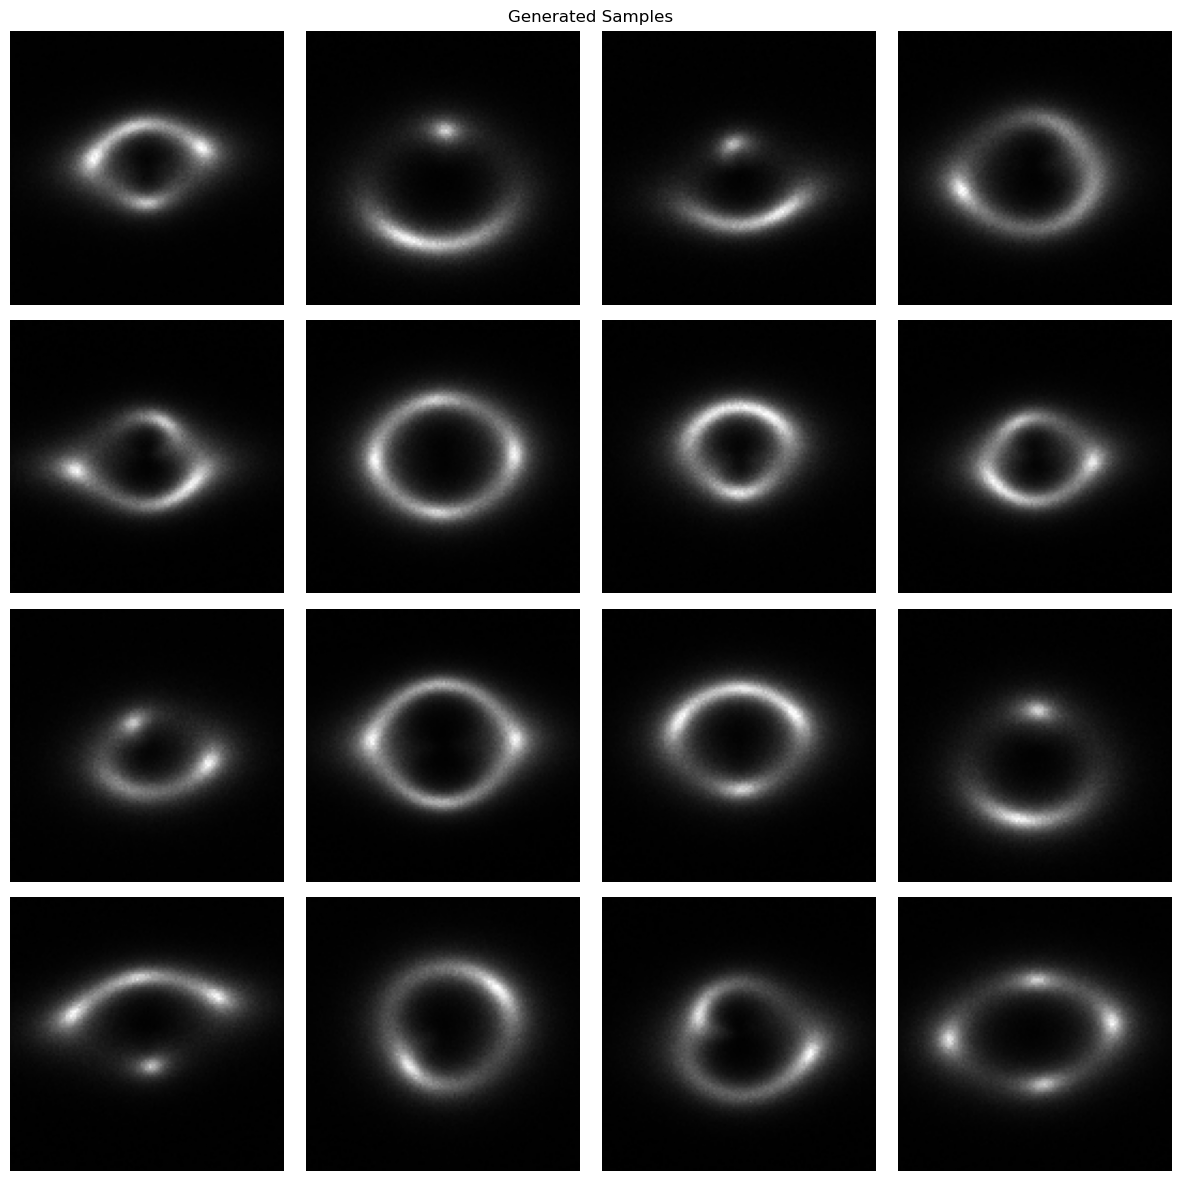

In [11]:
# Load trained model and sample
# trainer.load(str(trainer.results_folder / 'model-10.pt'))  # Load a checkpoint if needed

sampled_images = trainer.ema.ema_model.sample(batch_size=16)

fig, axs = plt.subplots(4, 4, figsize=(12, 12))
for i in range(16):
    row, col = i // 4, i % 4
    img = sampled_images[i].cpu().detach().numpy()
    img = np.transpose(img, (1, 2, 0))
    axs[row, col].imshow(img, cmap='gray')
    axs[row, col].axis('off')

plt.suptitle('Generated Samples')
plt.tight_layout()
plt.savefig(str(trainer.results_folder / 'final_samples.png'), dpi=150)
plt.show()

In [13]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 86.4 MB/s eta 0:00:00


In [15]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import DataLoader
from multiprocessing import cpu_count

def calculate_fid(trainer, num_samples=2500):
    """Calculate FID score between real and generated images"""
    
    # Get real images
    dataset = LensingDataset(image_path, image_size=128)
    dl = DataLoader(dataset, batch_size=num_samples, shuffle=True, pin_memory=True, num_workers=cpu_count())
    iterator = iter(dl)
    real_images = next(iterator)
    
    # Generate samples
    print(f"Generating {num_samples} samples...")
    sampled_images = trainer.ema.ema_model.sample(batch_size=100)
    for i in tqdm(range(num_samples // 100 - 1)):
        temp = trainer.ema.ema_model.sample(batch_size=100)
        sampled_images = torch.cat((sampled_images, temp), dim=0)
    
    print(f"Generated {sampled_images.shape[0]} samples")
    
    # Prepare for FID calculation
    sampled_images = sampled_images * 255
    sampled_images = sampled_images.to('cuda').to(torch.uint8)
    sampled_images = sampled_images.repeat(1, 3, 1, 1)  # Convert to RGB
    
    real_images = real_images.to('cuda') * 255
    real_images = real_images.to(torch.uint8)
    real_images = real_images.repeat(1, 3, 1, 1)  # Convert to RGB
    
    # Calculate FID
    fid = FrechetInceptionDistance(feature=2048, normalize=False)
    fid.to('cuda')
    
    print("Computing FID...")
    for i in tqdm(range(num_samples // 100)):
        fid.update(real_images[100*i:100*(i+1)], real=True)
        fid.update(sampled_images[100*i:100*(i+1)], real=False)
    
    fid_score = fid.compute()
    return fid_score, sampled_images

# ===== CALCULATE AND PRINT FID =====
fid_score, generated_samples = calculate_fid(trainer, num_samples=2500)

print("=" * 50)
print(f"FID SCORE: {fid_score.item():.2f}")
print("=" * 50)

# Save generated samples for later use
torch.save(generated_samples, str(trainer.results_folder / 'generated_samples.pt'))
print(f"Saved generated samples to {trainer.results_folder / 'generated_samples.pt'}")

Generating 2500 samples...


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


  0%|          | 0/24 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Generated 2500 samples


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/jovyan/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 237MB/s]


Computing FID...


  0%|          | 0/25 [00:00<?, ?it/s]

FID SCORE: 3.80
Saved generated samples to /home/jovyan/work/pinn/super_image/results/generated_samples.pt
